任务一：长度计算

In [ ]:
import numpy as np

v = np.array([2.,3.])
w = np.array([4.,1.])

def length_cal(v):
    len2 = np.inner(v,v)#本质上等价np.dot(v,v)，详见day5.md**关键直觉**
    lenth = np.sqrt(len2)
    return lenth

def geometric_cal(v,w):
    v_len = length_cal(v)
    w_len = length_cal(w)

    θ_v = np.arctan2(v[1], v[0])
    θ_w = np.arctan2(w[1], w[0])
    θ = θ_v - θ_w
    cos = np.cos(θ)

    result = v_len * w_len * cos#|v||w|*cos
    return result

dotted = geometric_cal(v,w)
dotted_truth = np.dot(v,w)

print(dotted, dotted_truth)

任务二：投影可视化——画 v、w 箭头 + 投影箭头  (w·v / v·v)·v ，肉眼验证投影长度 = cos θ × ‖w‖

投影向量: [1.69230769 2.53846154]
投影长度 = 3.0509, cosθ × ‖w‖ = 3.0509, 相差 0.00e+00
e·v = 0.00e+00（应为 0，验证 e ⊥ v）


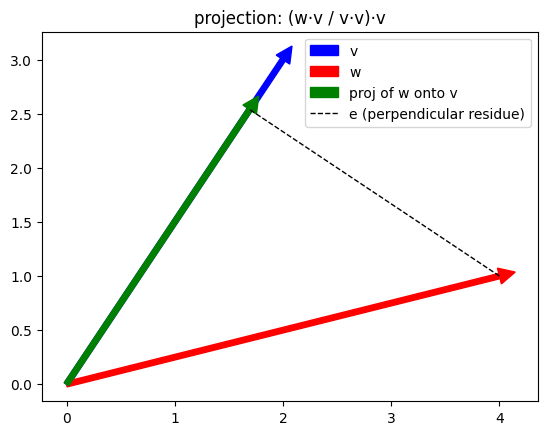

In [3]:
import matplotlib.pyplot as plt
import numpy as np

v = np.array([2.,3.])
w = np.array([4.,1.])

v_proj = (np.dot(w, v) / np.dot(v, v)) * v
e = w - v_proj   # 垂直残余：w 减掉投影后剩下的部分，应垂直于 v

theta = np.arctan2(v[1], v[0]) - np.arctan2(w[1], w[0])
proj_len = np.linalg.norm(v_proj)
check_len = np.cos(theta) * np.linalg.norm(w)
print('投影向量:', v_proj)
print('投影长度 = %.4f, cosθ × ‖w‖ = %.4f, 相差 %.2e' % (proj_len, check_len, abs(proj_len - check_len)))
print('e·v = %.2e（应为 0，验证 e ⊥ v）' % np.dot(e, v))

plt.arrow(0, 0, v[0], v[1], width=0.05, head_width=0.15, head_length=0.15, color='b', label='v')
plt.arrow(0, 0, w[0], w[1], width=0.05, head_width=0.15, head_length=0.15, color='r', label='w')
plt.arrow(0, 0, v_proj[0], v_proj[1], width=0.05, head_width=0.15, head_length=0.15, color='g', label='proj of w onto v')
plt.plot([w[0], v_proj[0]], [w[1], v_proj[1]], 'k--', lw=1, label='e (perpendicular residue)')
plt.axis('equal')
plt.legend()
plt.title('projection: (w·v / v·v)·v')
plt.show()

任务三：正交检验——随机 20 个向量，点积找出所有与 (1,1) 正交的，观察落点连成什么

20 个随机向量中与 (1,1) 点积≈0（atol=0.5）的有 2 个
连续随机撞精确 0 的概率为 0 —— 命中的是"接近正交"，不是"正交"


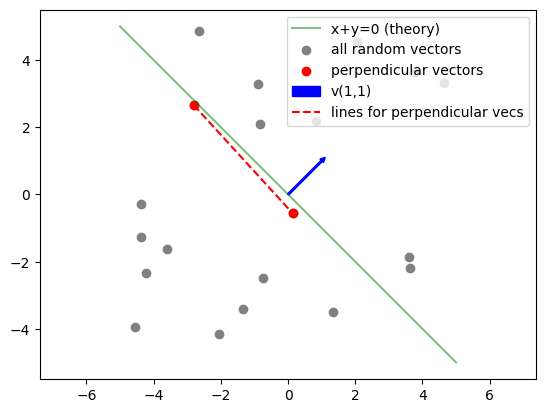

In [140]:
import matplotlib.pyplot as plt
import numpy as np

v = np.array([1.,1.])
vecs = np.random.uniform(-5, 5, size=(20, 2))
dots = vecs @ v
mask = np.isclose(dots, 0, atol=0.5)
near_ortho = vecs[mask]
#print(vecs,"\n",dots)
t = np.linspace(-5, 5, 100)
ortho_line = np.column_stack([t, -t])
plt.plot(ortho_line[:, 0], ortho_line[:, 1], 'g-', alpha=0.5, label='x+y=0 (theory)')
plt.scatter(vecs[:, 0], vecs[:, 1], c='gray', label='all random vectors')
plt.scatter(near_ortho[:, 0], near_ortho[:, 1], c='red', label='perpendicular vectors')
plt.arrow(0, 0, v[0], v[1], width=0.05, head_width=0.15, head_length=0.15, color='blue', label='v(1,1)')
plt.plot(near_ortho[:, 0], near_ortho[:, 1], 'r--', label='lines for perpendicular vecs')
plt.legend()
plt.axis('equal')
print(f'20 个随机向量中与 (1,1) 点积≈0（atol=0.5）的有 {mask.sum()} 个')
print('连续随机撞精确 0 的概率为 0 —— 命中的是"接近正交"，不是"正交"')

## 任务 4：相似度罗盘——给三个月后的注意力机制埋一颗直觉炸弹

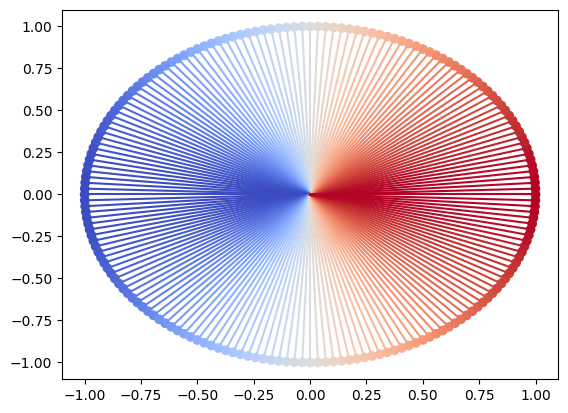

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

u = np.array([1,0])

angles = np.linspace(0, 2*np.pi, 180, endpoint=False)

xs = np.cos(angles)
ys = np.sin(angles)
w_vecs = np.column_stack([xs, ys])
dots = w_vecs @ u
cmap = plt.cm.coolwarm
colors = cmap((dots + 1) / 2)
plt.scatter(xs, ys, c=dots, cmap=cmap, vmin=-1, vmax=1)
for i in range(len(dots)):
    plt.plot([0, w_vecs[i,0]], [0, w_vecs[i,1]], color=colors[i])
plt.axis('equal')
plt.colorbar(label='u·w')


“注意力 =
每个词拿着自己的罗盘找同色系的词”